In [17]:
import pandas as pd 
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
import itertools
import math

# Load Data (if it doesn't already exist)

In [2]:
# load embeddings 
cpi3m_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"
df_emb = pd.read_parquet(cpi3m_path)

# dimensionality of embeddings
cls_dim = len(df_emb['cls_features'].iloc[0])
head_dim = len(df_emb['head_features'].iloc[0])

print("Dimensionality of cls_features:", cls_dim)
print("Dimensionality of head_features:", head_dim)

Dimensionality of cls_features: 384
Dimensionality of head_features: 64


Load COCPIT VGG16 labels and estimated particle metrics

In [3]:
# -------------------------------
# Parameters
# -------------------------------
data_dir = '/home/jko/cocpit/final_databases/vgg16/jk-modified'
label_col = 'classification'
features_to_find = ['particle width', 'particle height']  # base strings to search

# -------------------------------
# Step 1: Find all CSV files
# -------------------------------
csv_files = list(Path(data_dir).glob('*.csv'))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

# -------------------------------
# Step 2: Identify columns robustly
# -------------------------------
# Read headers only
cols_by_file = [pd.read_csv(f, nrows=0).columns for f in csv_files]

# Normalize columns
cols_by_file_norm = [[c.lower().strip() for c in cols] for cols in cols_by_file]

# Columns common to all CSVs (ignoring case/whitespace)
common_cols_norm = set(cols_by_file_norm[0])
for cols in cols_by_file_norm[1:]:
    common_cols_norm &= set(cols)

# Map normalized names back to actual column names from the first CSV
first_csv_cols = cols_by_file[0]
common_cols_actual = [c for c in first_csv_cols if c.lower().strip() in common_cols_norm]

print(f"Common columns loaded ({len(common_cols_actual)}): {common_cols_actual}")

# -------------------------------
# Step 3: Load each CSV, including particle width/height if present
# -------------------------------
dfs = []

for f in csv_files:
    # Read header
    cols = pd.read_csv(f, nrows=0).columns
    # Detect particle width/height columns
    particle_width_col = next((c for c in cols if 'particle width' in c.lower()), None)
    particle_height_col = next((c for c in cols if 'particle height' in c.lower()), None)
    
    # Columns to load: common + detected particle width/height
    cols_to_load = list(common_cols_actual)
    if particle_width_col and particle_width_col not in cols_to_load:
        cols_to_load.append(particle_width_col)
    if particle_height_col and particle_height_col not in cols_to_load:
        cols_to_load.append(particle_height_col)
    
    # Load CSV
    tmp = pd.read_csv(f, usecols=cols_to_load)
    tmp['campaign'] = f.stem  # assign campaign
    dfs.append(tmp)

# Combine all
df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined DataFrame shape: {df.shape}")

# -------------------------------
# Step 4: Canonicalize classification labels
# -------------------------------
LABEL_MAP = {
    "aggregate": "aggregate", "agg": "aggregate",
    "compact irregular": "compact_irregular", "compact_irreg": "compact_irregular",
    "planar polycrystal": "planar_polycrystal", "planar_polycrystal": "planar_polycrystal",
    "bullet rosette": "bullet_rosette", "bullet": "bullet_rosette",
    "budding rosette": "budding_rosette", "budding": "budding_rosette",
    "sphere": "sphere", "column": "column", "fragment": "fragment", "rimed": "rimed",
}

df[label_col] = df[label_col].str.lower().map(LABEL_MAP)

# -------------------------------
# Step 5: Rename particle width/height to canonical names
# -------------------------------
# Pick the first matching column in the DataFrame
particle_width_col = next((c for c in df.columns if 'particle width' in c.lower()), None)
particle_height_col = next((c for c in df.columns if 'particle height' in c.lower()), None)

if particle_width_col:
    df['particle_width'] = df[particle_width_col]
if particle_height_col:
    df['particle_height'] = df[particle_height_col]

print(f"\nColumns after adding particle_width/height: {df.columns.tolist()}")

# -------------------------------
# Step 6: Sanity checks
# -------------------------------
print("\nFinal label counts:")
print(df[label_col].value_counts())

unmapped = df.loc[df[label_col].isna(), label_col].unique()
if len(unmapped) > 0:
    print("\n⚠️ Unmapped labels found:")
    print(unmapped)
else:
    print("\n✅ All labels successfully mapped")

# -------------------------------
# Step 7: Count samples per campaign
# -------------------------------
samples_per_campaign = df['campaign'].value_counts()
print("\nNumber of samples per campaign:")
print(samples_per_campaign)

# -------------------------------
# Step 8: Done
# -------------------------------
df_cocpit = df
print("\nDataFrame ready with particle_width and particle_height added:")
print(df_cocpit.head())

# -------------------------------
# Detect all particle width / height columns
# -------------------------------
particle_width_cols = [c for c in df_cocpit.columns if 'particle width' in c.lower() or 'particle_width' in c.lower()]
particle_height_cols = [c for c in df_cocpit.columns if 'particle height' in c.lower() or 'particle_height' in c.lower()]

print(f"Detected particle width columns: {particle_width_cols}")
print(f"Detected particle height columns: {particle_height_cols}")

# -------------------------------
# Combine into unified columns using first non-null value
# -------------------------------
df_cocpit['particle_width'] = df_cocpit[particle_width_cols].bfill(axis=1).iloc[:, 0]
df_cocpit['particle_height'] = df_cocpit[particle_height_cols].bfill(axis=1).iloc[:, 0]

# -------------------------------
# Drop the original redundant columns
# -------------------------------
df_cocpit = df_cocpit.drop(columns=set(particle_width_cols + particle_height_cols) - set(['particle_width', 'particle_height']))

# -------------------------------
# Check results
# -------------------------------
print("Columns after unification:")
print(df_cocpit.columns)

print("\nCheck particle_width / particle_height data:")
print(df_cocpit[['particle_width', 'particle_height']].head())

Common columns loaded (14): ['filename', 'date', 'classification', 'blur', 'contrast', 'circularity', 'solidity', 'complexity', 'equiv_d', 'phi', 'extreme_points', 'filled_circular_area_ratio', 'roundness', 'perim_area_ratio']

Combined DataFrame shape: (1060926, 19)

Columns after adding particle_width/height: ['filename', 'date', 'particle width [microns]', 'particle height [microns]', 'classification', 'blur', 'contrast', 'circularity', 'solidity', 'complexity', 'equiv_d', 'phi', 'extreme_points', 'filled_circular_area_ratio', 'roundness', 'perim_area_ratio', 'campaign', 'particle width', 'particle height', 'particle_width', 'particle_height']

Final label counts:
classification
compact_irregular     534637
aggregate             214006
planar_polycrystal    102280
rimed                  97693
column                 45193
budding_rosette        33396
bullet_rosette         26617
sphere                  6864
fragment                 240
Name: count, dtype: int64

✅ All labels successf

In [4]:
# merge cocpit and embeddings df's 

# Merge df_emb and df_cocpit on 'campaign' and 'filename'
df_merged = pd.merge(
    df_emb,
    df_cocpit,
    on=['campaign', 'filename'],
    how='inner'  # use 'inner' to keep only matching rows
)

print(f"Merged DataFrame shape: {df_merged.shape}")
df_merged.head()

Merged DataFrame shape: (937237, 20)


,campaign_file_id,cls_features,campaign,filename,head_features,date,classification,blur,contrast,circularity,solidity,complexity,equiv_d,phi,extreme_points,filled_circular_area_ratio,roundness,perim_area_ratio,particle_width,particle_height
0,AIRS_II/2003_1114_134317_724_13.png,"[0.2910927, 0.38144028, 1.1725152, -0.4043146,...",AIRS_II,2003_1114_134317_724_13.png,"[0.10949938, 0.06253101, -0.06456344, 0.338093...",2003-11-14 13:43:17,budding_rosette,29.494,87.158,0.383,0.817,0.596,769.296,0.834,330.573,0.571,0.720,0.008,181.132,216.466
1,AIRS_II/2003_1114_134317_724_14.png,"[-0.9387017, 2.2442503, 1.0302829, -1.5016816,...",AIRS_II,2003_1114_134317_724_14.png,"[-0.099237524, -0.072814986, -0.01931724, 0.22...",2003-11-14 13:43:17,budding_rosette,18.941,81.149,0.209,0.742,0.766,738.851,0.894,357.990,0.505,0.640,0.012,161.984,193.049
2,AIRS_II/2003_1114_134317_724_17.png,"[0.26718536, 1.0774301, 0.08947551, -1.1187441...",AIRS_II,2003_1114_134317_724_17.png,"[0.058383655, 0.053461675, -0.071571335, 0.360...",2003-11-14 13:43:17,budding_rosette,27.279,90.875,0.278,0.745,0.687,755.328,0.972,338.392,0.500,0.646,0.010,195.634,199.894
3,AIRS_II/2003_1114_134317_724_18.png,"[-0.81129575, 2.301869, 1.2609062, -0.8582968,...",AIRS_II,2003_1114_134317_724_18.png,"[-0.19895327, -0.09332458, -0.06524665, 0.1968...",2003-11-14 13:43:17,compact_irregular,23.879,89.105,0.272,0.799,0.735,733.868,0.870,303.559,0.668,0.742,0.010,109.099,197.747
4,AIRS_II/2003_1114_134317_724_39.png,"[0.3733411, -1.1279708, -1.072373, -0.79710406...",AIRS_II,2003_1114_134317_724_39.png,"[-0.06219735, 0.20381087, 0.018670687, 0.16595...",2003-11-14 13:43:17,compact_irregular,26.745,90.298,0.315,0.753,0.649,710.312,0.997,325.416,0.508,0.656,0.010,122.374,122.261


In [6]:
# print number of samples in each campaign
print(df_merged['campaign'].value_counts().sort_index())
print("\nTotal samples:", df_merged['campaign'].value_counts().sum())

campaign
AIRS_II               27303
ARM                   23959
ATTREX                19637
CRYSTAL_FACE_NASA     61858
CRYSTAL_FACE_UND     396138
ICE_L                 37019
IPHEX                 16900
ISDAC                 73394
MACPEX                 2226
MC3E                 160630
MIDCIX                88857
MPACE                 29316
Name: count, dtype: int64

Total samples: 937237


In [7]:
df_merged.columns

Index(['campaign_file_id', 'cls_features', 'campaign', 'filename',
       'head_features', 'date', 'classification', 'blur', 'contrast',
       'circularity', 'solidity', 'complexity', 'equiv_d', 'phi',
       'extreme_points', 'filled_circular_area_ratio', 'roundness',
       'perim_area_ratio', 'particle_width', 'particle_height'],
      dtype='object')

In [8]:
# save the merged file
merged_out = '../data/emb_cocpit_vgg16_merged.parquet'
df_merged.to_parquet(merged_out)

# Load data if it already exists

In [2]:
merged_out = '../data/emb_cocpit_vgg16_merged.parquet'
df_merged = pd.read_parquet(merged_out)

In [3]:
df_merged.shape

(937237, 20)

# Dimensionality Reduction + Viz

In [4]:
# number of samples in each class
df_merged['classification'].value_counts()

classification
compact_irregular     505674
aggregate             180264
rimed                  80349
planar_polycrystal     72838
column                 35641
budding_rosette        32877
bullet_rosette         24667
sphere                  4793
fragment                 134
Name: count, dtype: int64

In [5]:
# get rid of fragment class for analysis --> 8 total classes now
df_merged = df_merged[df_merged['classification'] != 'fragment']
df_merged['classification'].value_counts()

classification
compact_irregular     505674
aggregate             180264
rimed                  80349
planar_polycrystal     72838
column                 35641
budding_rosette        32877
bullet_rosette         24667
sphere                  4793
Name: count, dtype: int64

In [20]:
# sample 4000 from each class 
df_subset = (
    df_merged
    .groupby('classification', group_keys=False)
    .sample(n=4000, random_state=42)
    .reset_index(drop=True)
)

## PCA

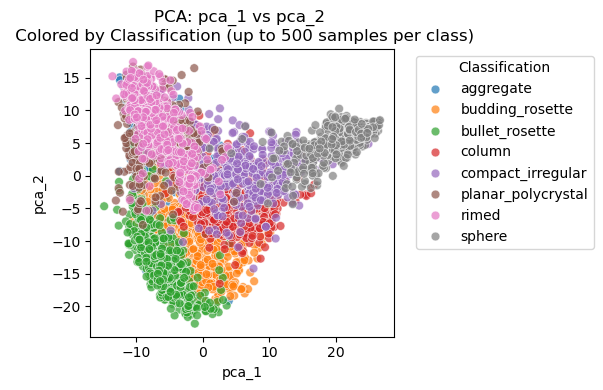

In [11]:
# run PCA
X = np.vstack(df_subset['cls_features'].values)
n_pca = 10
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X)

# build new pca df 
pca_cols = [f"pca_{i+1}" for i in range(n_pca)]
df_pca = df_subset.copy()
df_pca[pca_cols] = X_pca

# which PCA components to plot
x_col, y_col = "pca_1", "pca_2"
label_col = "classification"

# -------------------------------
# Subsample up to N per class
# -------------------------------
N = 500  # max samples per class
dfs = []
for cls, group in df_pca.groupby(label_col):
    dfs.append(group.sample(n=min(len(group), N), random_state=42))

df_plot = pd.concat(dfs, ignore_index=True)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_plot,
    x=x_col,
    y=y_col,
    hue=label_col,
    palette="tab10",
    alpha=0.7,
    s=40
)

plt.title(f"PCA: {x_col} vs {y_col} \n Colored by Classification (up to {N} samples per class)")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## UMAP

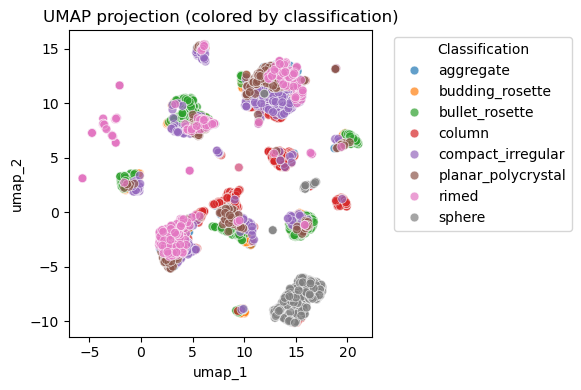

In [12]:
# -------------------------------
# UMAP projection
# -------------------------------
X = np.vstack(df_subset['cls_features'].values)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # controls local vs global structure
    min_dist=0.1,       # tighter clusters if smaller
    n_jobs=-1,          # not compatible with random_state
    # random_state=42
)

X_umap = umap_model.fit_transform(X)

# build df
df_umap = df_subset.copy()
df_umap["umap_1"] = X_umap[:, 0]
df_umap["umap_2"] = X_umap[:, 1]

# -------------------------------
# Subsample per class (same as before)
# -------------------------------
N = 500
dfs = []
for cls, group in df_umap.groupby("classification"):
    dfs.append(group.sample(n=min(len(group), N), random_state=42))

df_plot = pd.concat(dfs, ignore_index=True)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6, 4))

palette = 'tab10'

sns.scatterplot(
    data=df_plot,
    x="umap_1",
    y="umap_2",
    hue="classification",
    palette=palette,
    alpha=0.7,
    s=40
)

plt.title("UMAP projection (colored by classification)")
plt.xlabel("umap_1")
plt.ylabel("umap_2")
plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## t-SNE

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 2.108s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 7.187716
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.848450
[t-SNE] KL divergence after 1000 iterations: 1.312035


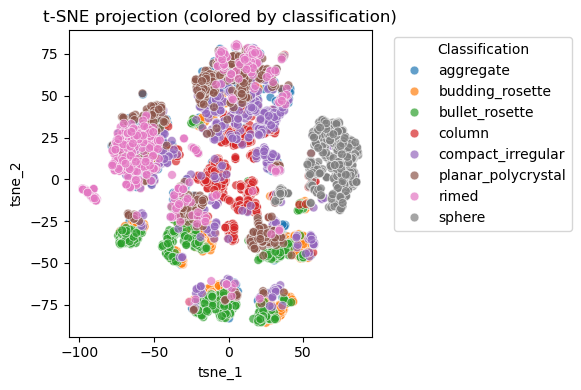

In [16]:
# -------------------------------
# t-SNE projection (correct + safe)
# -------------------------------

# Use the same subset you already created (df_subset OR df_plot)
X = np.vstack(df_subset['cls_features'].values)

# Optional: subsample further for speed
n_tsne = 10000
if len(X) > n_tsne:
    idx = np.random.choice(len(X), size=n_tsne, replace=False)
    X = X[idx]
    df_tsne_base = df_subset.iloc[idx].reset_index(drop=True)
else:
    df_tsne_base = df_subset.copy()

tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne_model.fit_transform(X)

# build df
df_tsne = df_tsne_base.copy()
df_tsne["tsne_1"] = X_tsne[:, 0]
df_tsne["tsne_2"] = X_tsne[:, 1]

# -------------------------------
# Subsample per class (for plotting)
# -------------------------------
N = 500
dfs = []
for cls, group in df_tsne.groupby("classification"):
    dfs.append(group.sample(n=min(len(group), N), random_state=42))

df_plot = pd.concat(dfs, ignore_index=True)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_plot,
    x="tsne_1",
    y="tsne_2",
    hue="classification",
    palette="tab10",
    alpha=0.7,
    s=40
)

plt.title("t-SNE projection (colored by classification)")
plt.xlabel("tsne_1")
plt.ylabel("tsne_2")
plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## PCA 2-d slices

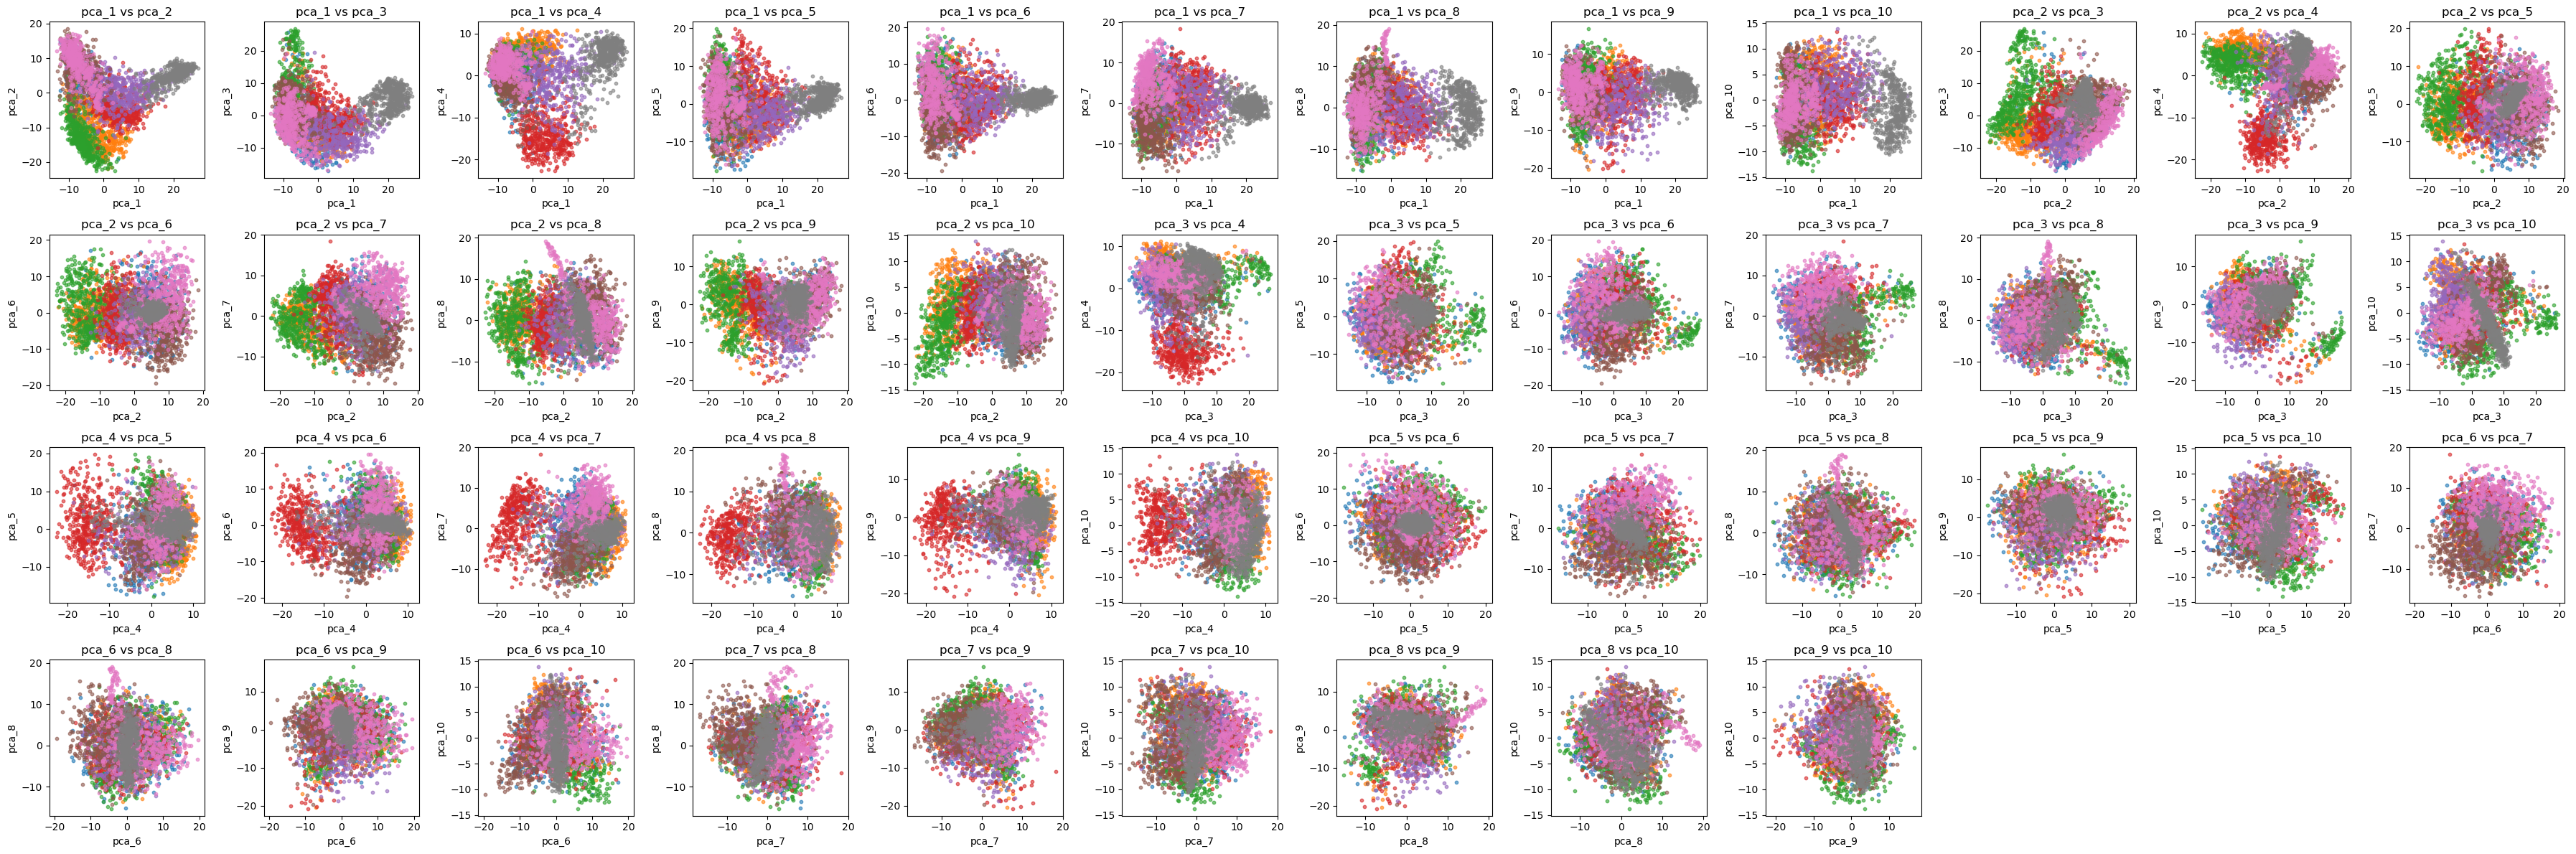

In [22]:
# -------------------------------
# Ensure df_pca is correct (rebuild safely)
# -------------------------------
df_pca = df_subset.copy()
df_pca[pca_cols] = X_pca

# -------------------------------
# Balanced subsample (500/class)
# -------------------------------
df_balanced = (
    df_pca
    .groupby('classification', group_keys=False)
    .sample(n=500, random_state=42)
    .reset_index(drop=True)
)

# -------------------------------
# Pairwise PCA combinations
# -------------------------------
pairs = list(itertools.combinations(pca_cols, 2))
n_pairs = len(pairs)

# -------------------------------
# Force ~3:1 width:height
# -------------------------------
n_rows = int(np.ceil(np.sqrt(n_pairs / 3)))
n_cols = int(np.ceil(n_pairs / n_rows))

# -------------------------------
# Figure size (preserve ratio)
# -------------------------------
fig_size = 3  # base scaling
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * fig_size, n_rows * fig_size)
)
axes = axes.flatten()

# -------------------------------
# Plot
# -------------------------------
for i, (x_col, y_col) in enumerate(pairs):
    ax = axes[i]
    
    for cls, sub in groups.items():
        ax.scatter(sub[x_col], sub[y_col], s=10, alpha=0.6)
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.grid(False)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Pairwise logistic regression decision boundary

/home/jko/.local/share/mamba/envs/emb_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/jko/.local/share/mamba/envs/emb_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 0.8542708333333333


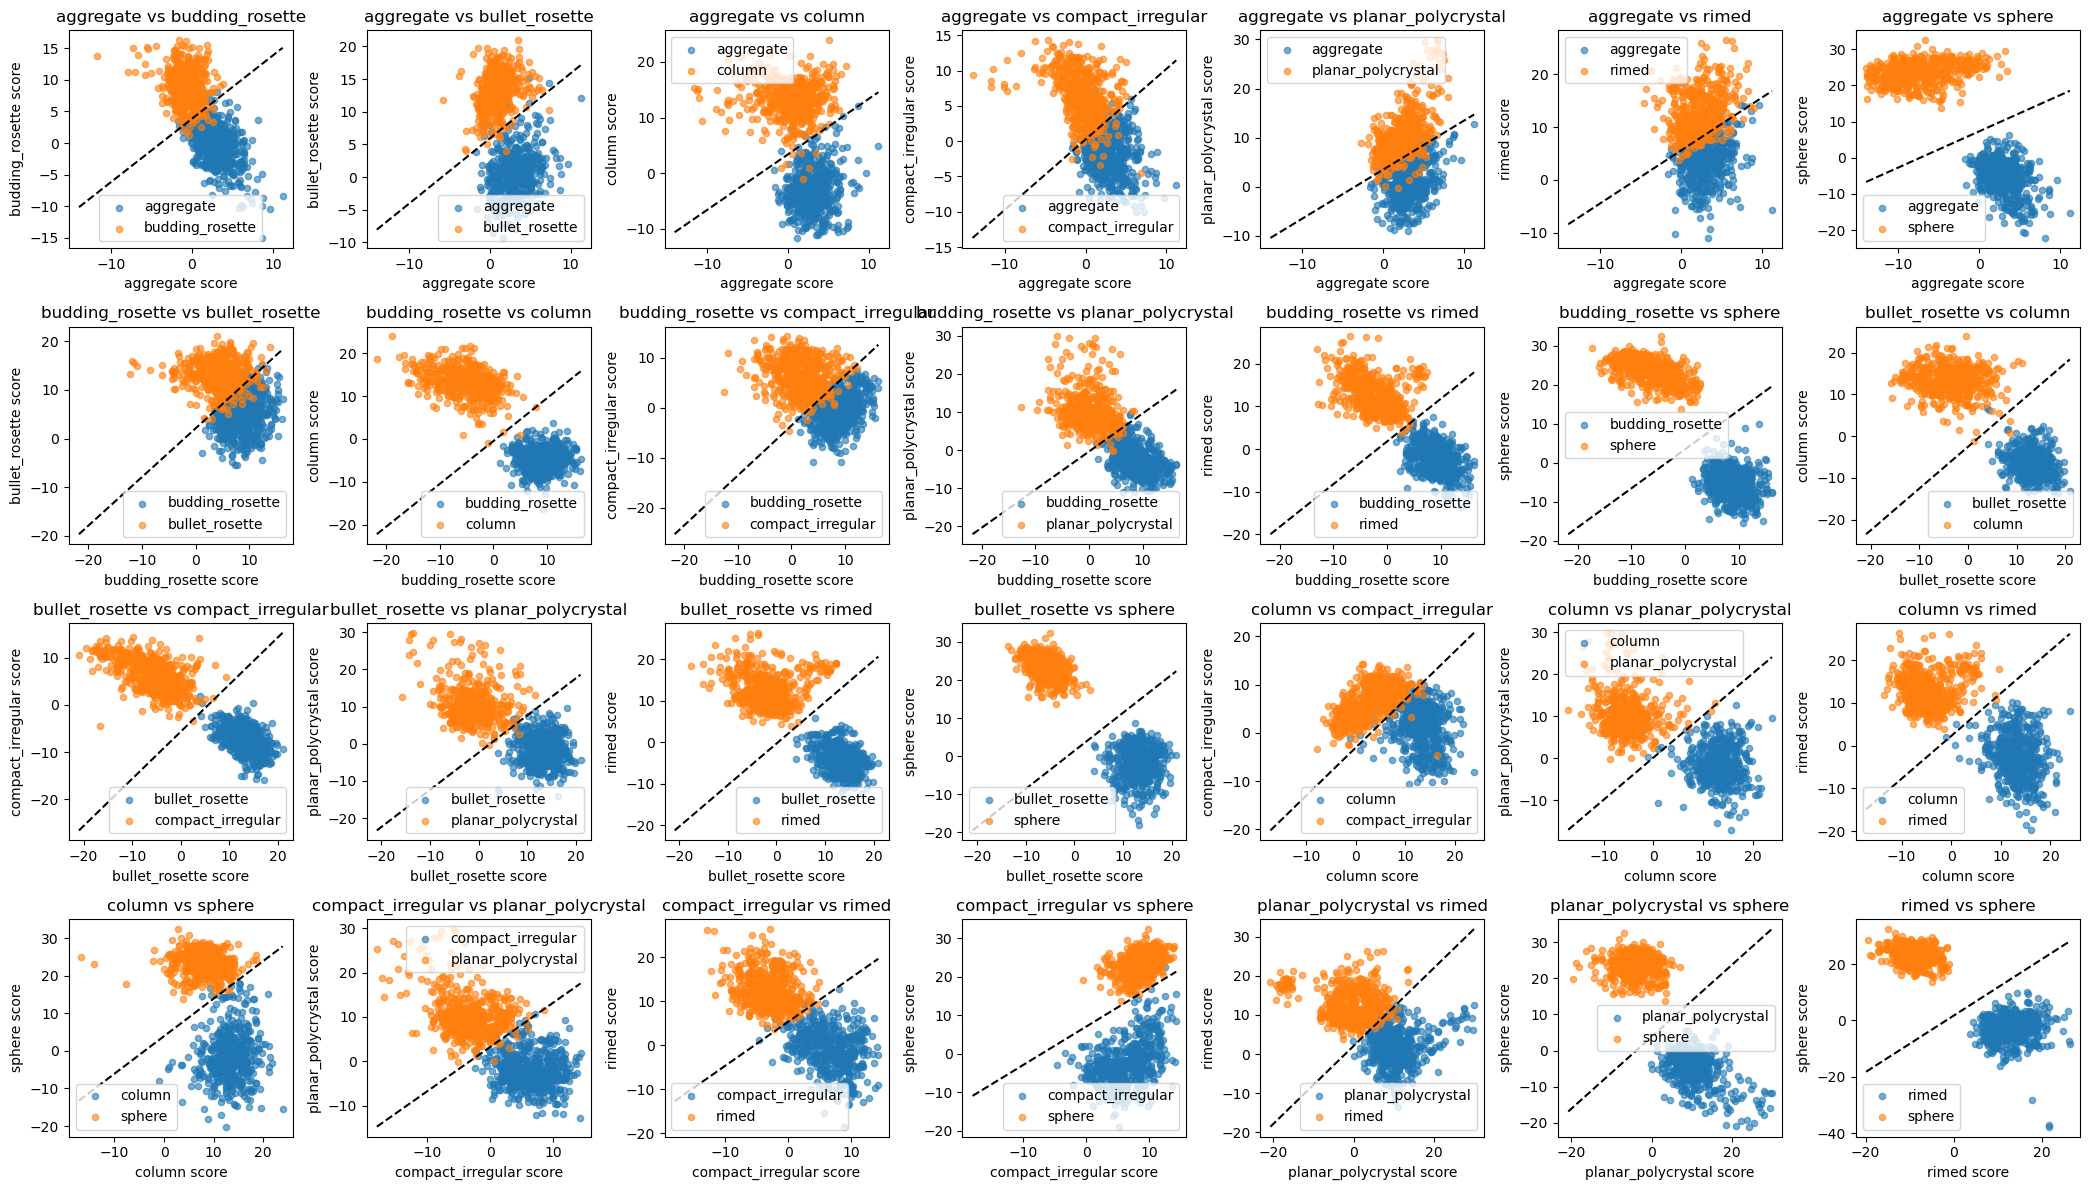

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -----------------------------
# Build X, y from df_subset
# -----------------------------
X = np.vstack(df_subset['cls_features'].values)
y = df_subset['classification'].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.3,
    random_state=666,
    stratify=y_enc
)

# -----------------------------
# Scale (fit on train only)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Train logistic regression
# -----------------------------
clf = LogisticRegression(
    solver='saga',
    max_iter=2000,
    random_state=666
)
clf.fit(X_train_scaled, y_train)

# -----------------------------
# Quick evaluation (optional)
# -----------------------------
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

# -----------------------------
# Extract model params
# -----------------------------
weights = clf.coef_
bias = clf.intercept_

# -----------------------------
# Build visualization subset (500/class)
# -----------------------------
X_all = X
y_all = y_enc

X_all_scaled = scaler.transform(X_all)

N_plot = 500
indices = []

for c in np.unique(y_all):
    cls_idx = np.where(y_all == c)[0]
    if len(cls_idx) > N_plot:
        cls_idx = np.random.choice(cls_idx, N_plot, replace=False)
    indices.append(cls_idx)

indices = np.concatenate(indices)

X_vis = X_all_scaled[indices]
y_vis = y_all[indices]

# -----------------------------
# Pairwise class combinations
# -----------------------------
class_indices = np.unique(y_vis)
pairs = list(combinations(class_indices, 2))
n_pairs = len(pairs)

# -----------------------------
# ~3:1 layout
# -----------------------------
n_rows = int(np.ceil(np.sqrt(n_pairs / 3)))
n_cols = int(np.ceil(n_pairs / n_rows))

fig_size = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*fig_size, n_rows*fig_size))
axes = axes.flatten()

# -----------------------------
# Plot projections + boundary
# -----------------------------
for i, (c1, c2) in enumerate(pairs):
    ax = axes[i]
    
    w1, w2 = weights[c1], weights[c2]
    b1, b2 = bias[c1], bias[c2]
    
    proj = X_vis @ np.vstack([w1, w2]).T
    x_vals = proj[:, 0]
    y_vals = proj[:, 1]
    
    for c in [c1, c2]:
        idx = y_vis == c
        ax.scatter(
            x_vals[idx], y_vals[idx],
            alpha=0.6, s=20,
            label=le.inverse_transform([c])[0]
        )
    
    # decision boundary: y = x + (b1 - b2)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = x_line + (b1 - b2)
    ax.plot(x_line, y_line, 'k--', linewidth=1.5)
    
    ax.set_xlabel(f'{le.inverse_transform([c1])[0]} score')
    ax.set_ylabel(f'{le.inverse_transform([c2])[0]} score')
    ax.set_title(f'{le.inverse_transform([c1])[0]} vs {le.inverse_transform([c2])[0]}')
    ax.grid(False)
    ax.legend(loc='best')

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()